In [1]:
import numpy as np
from numpy.polynomial import Polynomial
from matplotlib import pyplot as plt
from astroML.datasets import generate_mu_z
from astroML.linear_model import LinearRegression, PolynomialRegression
from sklearn.model_selection import train_test_split

/home/gabriele/anaconda3/envs/jupyter_env/lib/python3.11/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


(35.0, 50.0)

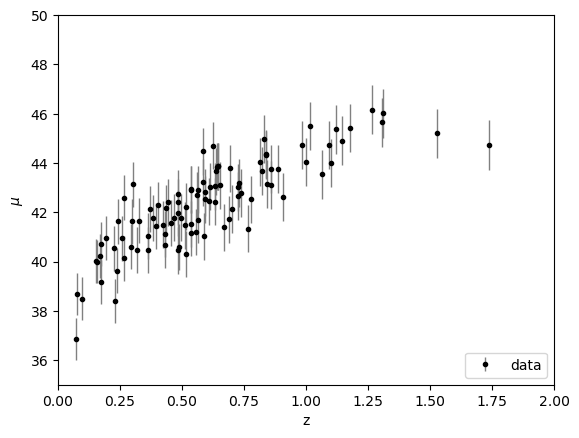

In [2]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # generating the sample

#preliminary plot of the data
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

We fit the data with polynomials of different degree

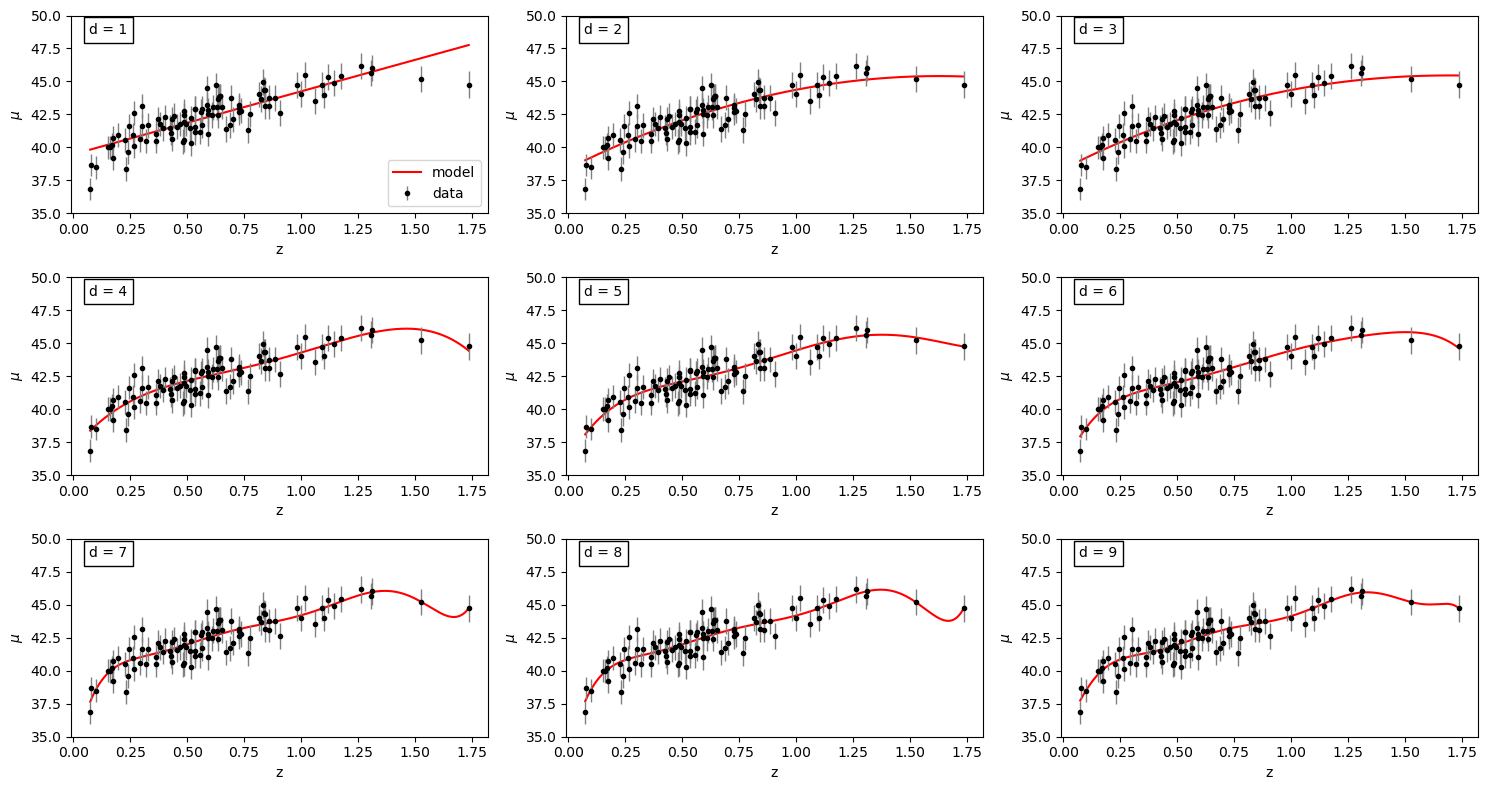

In [4]:
degree =  np.arange(1, 10) # polynomial degrees considered
z_sk = z_sample[:, np.newaxis]
x_grid = np.linspace(min(z_sample), max(z_sample), 10000)

fig, axes  =plt.subplots(3, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, d in enumerate(degree):
    
    pol_reg = PolynomialRegression(d) #fitting with d degree polynomial
    pol_reg.fit(z_sk, mu_sample, dmu)
    par = pol_reg.coef_
    model = np.array([np.polynomial.Polynomial(par)(x) for x in x_grid])
    
    #plotting the fitting plynomials over the data
    ax = axes[idx]
    ax.plot(x_grid, model, c='r', label='model')
    ax.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
    ax.set_xlabel("z")
    ax.set_ylabel("$\mu$")
    ax.set_ylim(35,50)
    ax.text(0.07, 48.6, "d = %i" % d, bbox=dict(ec='k', fc='w'))
    if (d==1):
        ax.legend()

plt.tight_layout()
plt.show()
  

At first glance, a linear fit seems very biased, and fits with $ d \geq 6$ seem to overfit the data


To pick the best degree to fit with we implement k fold cross validation 

In [5]:
#function to compute the rms error 
def rms_error (y, y_pred):

    sq_sum = 0.
    for i in range(len(y)):
        sq_sum += (y[i] - y_pred[i])*(y[i] - y_pred[i])
    
    err_sq = sq_sum/float(len(y))
    return np.sqrt(err_sq)

/tmp/ipykernel_10849/1096891536.py:49: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--k" (-> color='k'). The keyword argument will take precedence.
  plt.plot(degree, test_errs, '--k', c='black', label='training')


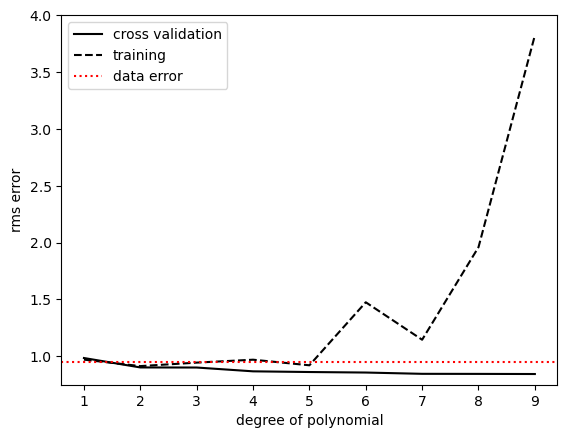

In [ ]:
k = 10 # number of folds in cross validation
test_len = int(len(z_sample)/k)

# vectors to store the errors for different values of d
train_errs = []
test_errs = []
min = 0

for d in degree:

    test_errs_d = []
    train_errs_d = []

    for i in range(k):
        
        #dividing the data into train and test(validation)
        if (i == k-1):
            test_index = np.arange(i*test_len, len(z_sample))
        else:
            test_index = np.arange(test_len) + i*test_len
        train_index = np.concatenate((np.arange(0, test_index[0]), np.arange(test_index[-1]+1, len(z_sample))))

        z_test = np.array([z_sample[j] for j in test_index])
        mu_test = np.array([mu_sample[j] for j in test_index])
        dmu_test = np.array([dmu[j] for j in test_index])
        z_train = np.array([z_sample[j] for j in train_index])
        mu_train = np.array([mu_sample[j] for j in train_index])
        dmu_train = np.array([dmu[j] for j in train_index])
        z_train_sk = z_train[:, np.newaxis]

        #fitting the training data with polynomial regression
        pol_reg = PolynomialRegression(d)
        pol_reg.fit(z_train_sk, mu_train, dmu_train)
        par = pol_reg.coef_
        
        #computing the rms errors on both the training and validation sets
        pol = Polynomial(par)
        mu_pred_train = np.array([pol(z) for z in z_train])
        mu_pred_test = np.array([pol(z) for z in z_test])
        train_errs_d.append(rms_error(mu_train, mu_pred_train))
        test_errs_d.append(rms_error(mu_test, mu_pred_test))
    
    #averaging the k results to get the errors associated to a given polynomial degree
    train_errs.append(np.mean(train_errs_d))
    test_errs.append(np.mean(test_errs_d))

# plotting the errors as a function of the hyperparameter(d)
plt.figure()
plt.plot(degree, train_errs, c='black', label='cross validation')
plt.plot(degree, test_errs, '--k', c='black', label='training')
plt.axhline(np.mean(dmu), ls='dotted', c='r', label='data error') # average error on the data
plt.xlabel('degree of polynomial')
plt.ylabel('rms error')
plt.ylim(0.75, 4.0)
plt.legend()

plt.show()

In [15]:
ranked_degrees = np.argsort(test_errs)+1

print(ranked_degrees)

[2 5 3 4 1 7 6 8 9]


From cross validation we see that best performance on the validation set is associated to $d = 2$ and $d = 5$, while the model starts to overfit the data starting from $d = 6$